# Email Agent
This notebook creates an agent to read an e-mail, classify it in terms of intent, urgency and content; and write a responde according.

Model Flow: <br />
![Model Flow](agent-flow.jpeg)


# Imports

In [1]:
from dotenv import load_dotenv

from langgraph.graph import END, START, StateGraph

from langgraph.types import Command, interrupt

from langgraph.checkpoint.memory import InMemorySaver

from typing import TypedDict, Literal

from IPython.display import Image, display

from langchain_anthropic import ChatAnthropic

load_dotenv()

True

# States Definitions

In [2]:
class EmailClassification(TypedDict):
    intent: Literal["question", "bug", "billing", "feature", "complex"]
    urgency: Literal["low", "medium", "high", "critical"]
    topic: str
    summary: str

class EmailAgentState(TypedDict):
    email_title: str
    email_body: str
    email_from: str
    email_classification: EmailClassification
    email_response: str


# Nodes Definitions

In [50]:
# TODO: parameterize the model by environment variable
llm = ChatAnthropic(model="claude-sonnet-4-5-20250929")

def read_email(state: EmailAgentState) -> EmailAgentState:
    """
    Read the email and returns the state with the email title, body, from, and classification.
    """
    pass

def classify_intent(state: EmailAgentState) -> EmailAgentState:
    """
    Use LLM to classify the intent of the email.
    """
    structured_llm = llm.with_structured_output(EmailClassification)

    prompt = f"""
    Classify the intent of the following email:
    Title: {state["email_title"]}
    Body: {state["email_body"]}
    From: {state["email_from"]}

    Provide classification, including intent, urgency, topic, and summary.
    """

    classification = structured_llm.invoke(state["email_body"])

    return {'email_classification': classification}

def bug_tracking(state: EmailAgentState) -> EmailAgentState:
    pass

def search_documentation(state: EmailAgentState) -> EmailAgentState:
    pass

def write_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """Write a response to the email based on the classification."""
    classification = state.get('email_classification', {})
    
    prompt = f"""
    Write a response to the email based on this e-mail:
    Title: {state["email_title"]}
    Body: {state["email_body"]}
    From: {state["email_from"]}

    The e-mail is classified as follows:
    Intent: {classification["intent"]}
    Urgency: {classification["urgency"]}
    Topic: {classification["topic"]}
    Summary: {classification["summary"]}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Be brief
    """

    response = llm.invoke(prompt)

    # Determine if human review is needed based on urgency and intent
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') == 'complex'
    )

    # Route to the appropriate next node
    if needs_review:
        goto = "human_review"
        print("The reply needs human approval before its sent.")
    else:
        goto = "send_reply"

    return Command(
        update = {"email_response": response.content},
        goto = goto
    )
    

def human_review(state: EmailAgentState) -> EmailAgentState:
    classification = state.get('classification', {})

    # Interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt({
        "email_title": state['email_title'],
        "email_content": state['email_body'],
        "email_from": state['email_from'],
        "draft_response": state.get('email_response', ""),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update = {"email_response": human_decision.get("edited_response", state['email_response'])},
            goto = "send_reply"
        )
    else:
        return Command(update = {}, goto = END)

def send_reply(state: EmailAgentState) -> EmailAgentState:
    """Send the reply to the email."""
    print(f"""
    This response will be sent to the email:

    {state['email_response']}
    """)

    # TODO: integrate with email service
    
    

# Graph Definition

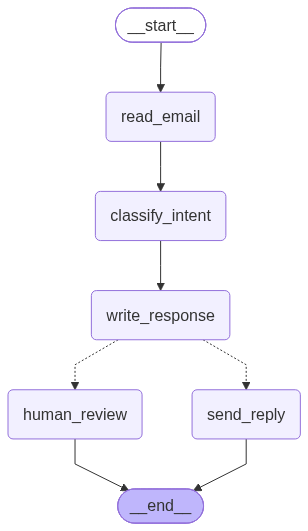

In [55]:
# Define the graph
builder = StateGraph(EmailAgentState)

# Define the nodes
read_email_node = builder.add_node("read_email", read_email)
classify_intent_node = builder.add_node("classify_intent", classify_intent)
# bug_tracking_node = builder.add_node("bug_tracking", bug_tracking)
# search_documentation_node = builder.add_node("search_documentation", search_documentation)
write_response_node = builder.add_node("write_response", write_response)
human_review_node = builder.add_node("human_review", human_review)
send_reply_node = builder.add_node("send_reply", send_reply)

# Define the edges

builder.add_edge(START, "read_email")
builder.add_edge("read_email", "classify_intent")
builder.add_edge("classify_intent", "write_response")
builder.add_edge("send_reply", END)

memory = InMemorySaver()
app = builder.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

In [56]:
# Test with urgent billing issue
initial_state = EmailAgentState(
    email_title="Double charge in my account",
    email_body="I was charged twice for my subscription. Please refund my account.",
    email_from="customer@example.com"
)

config = {"configurable": {"thread_id": "1"}}
result = app.invoke(initial_state, config)

The reply needs human approval before its sent.


In [57]:
from langgraph.types import Command

result = app.invoke(
    Command(
        resume={
            "approved": True
        }
    ),
    config
)


    This response will be sent to the email:

    **Subject:** RE: Double charge in my account

Dear Valued Customer,

Thank you for bringing this to our attention. I sincerely apologize for the duplicate charge on your account.

I'm escalating this issue to our billing team immediately to process your refund. You should see the duplicate charge reversed within 3-5 business days.

We'll send you a confirmation email once the refund has been processed. If you don't receive confirmation within 24 hours, please don't hesitate to reach out.

Again, we apologize for this error and any inconvenience it may have caused.

Best regards,

Customer Support Team
[Company Name]
[Contact Information]
    


In [58]:
# Test with not urgent issue
initial_state = EmailAgentState(
    email_title="Great service",
    email_body="I loved the service. Thank you very much for doing this!",
    email_from="customer@example.com"
)

config = {"configurable": {"thread_id": "2"}}
result = app.invoke(initial_state, config)


    This response will be sent to the email:

    **Subject:** RE: Great service

Dear Valued Customer,

Thank you so much for taking the time to share your positive feedback! We're delighted to hear that you were pleased with our service.

Customer satisfaction is our top priority, and comments like yours make our day. We truly appreciate your business and look forward to serving you again in the future.

If you ever need anything else, please don't hesitate to reach out.

Best regards,

[Your Name]
[Your Title]
[Company Name]
    
